<a href="https://colab.research.google.com/github/UMESHSINGH23/credit-risk-prediction-ml/blob/main/Copy_of_credit_card.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import os

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(BASE_DIR)
data_path = os.path.join(BASE_DIR, 'data', 'Loan_default (1).csv')

/


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv("Loan_default (1).csv")
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [27]:
df.drop('LoanID', axis=1, inplace=True)

## EDA

In [28]:
categorical = df.select_dtypes(include='object').columns
numerical = df.select_dtypes(include=['int', 'float']).columns

In [29]:
# A few color palette for aesthetic plots
# Check out all of them by individually executing them.
# Remember, aesthetics also add an interesting point for the flow of work.
mesh_1 = ['#AEFFBE','#94FFF1','#FFE48A','#FF9EBE']
sns.color_palette(mesh_1)
colors = ['#FF5851', '#F3C130', '#414A6B', '#B49A85', '#1C1B20']
sns.color_palette(colors)
colors_1 = ['#1D4851','#9AB5BC','#FF9001','#FF4701']
sns.color_palette(colors_1)
colors_2 = ['#0D110F','#6F8C64','#FDD584','#2A4731']
sns.color_palette(colors_2)
colors_3 = ['#0B0B11','#8288C3','#242961','#D0BED4']
sns.color_palette(colors_3)
colors_4 = ['#645CAA','#A084CA','#BFACE0','#EBC7E8']
sns.color_palette(colors_4)

[(0.39215686274509803, 0.3607843137254902, 0.6666666666666666),
 (0.6274509803921569, 0.5176470588235295, 0.792156862745098),
 (0.7490196078431373, 0.6745098039215687, 0.8784313725490196),
 (0.9215686274509803, 0.7803921568627451, 0.9098039215686274)]

In [30]:
def plot_data(column,clr):
    fig,axes = plt.subplots(1,3,figsize=(18,5))
    fig.suptitle(column,fontsize=20,fontstyle='oblique')
    sns.histplot(ax=axes[0], x=column, data=df, color=clr[1])
    axes[0].set_title(f'Histogram of {column}', fontsize=15)

    # Distribution (KDE)
    sns.kdeplot(ax=axes[1], x=df[column], color=clr[0], fill=True)
    axes[1].set_title(
        f'Distribution of {column}',
        fontstyle='italic',
        fontsize=15,
        color='black'
    )
    axes[1].set_xlabel(column)

    # Boxplot
    sns.boxplot(ax=axes[2], x=column, data=df, color=clr[3])
    plt.show()

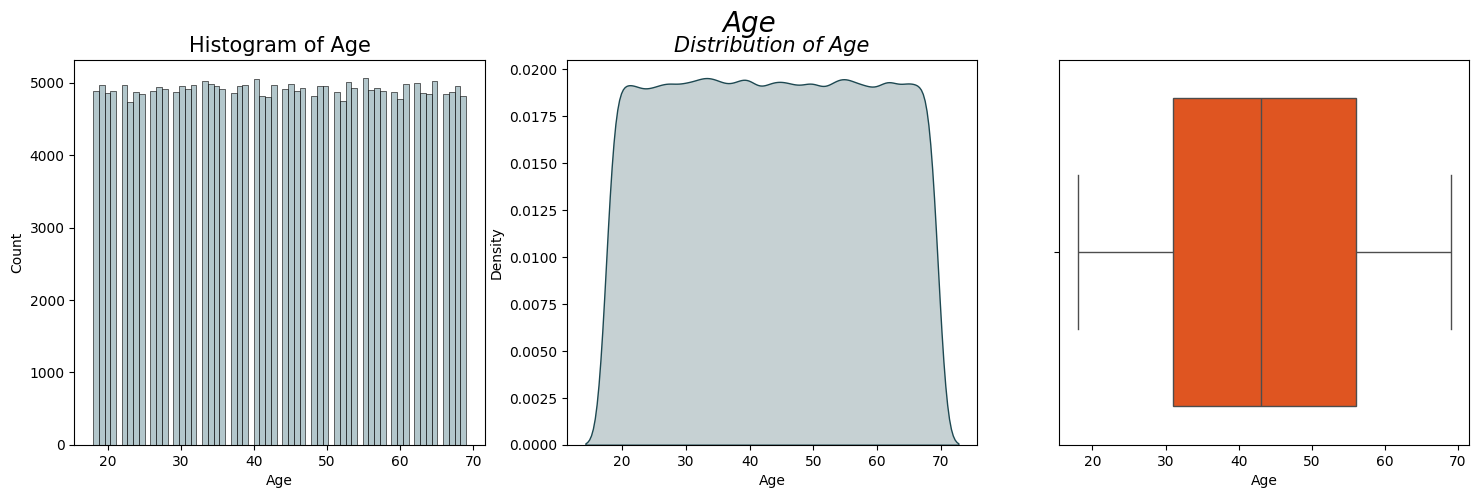

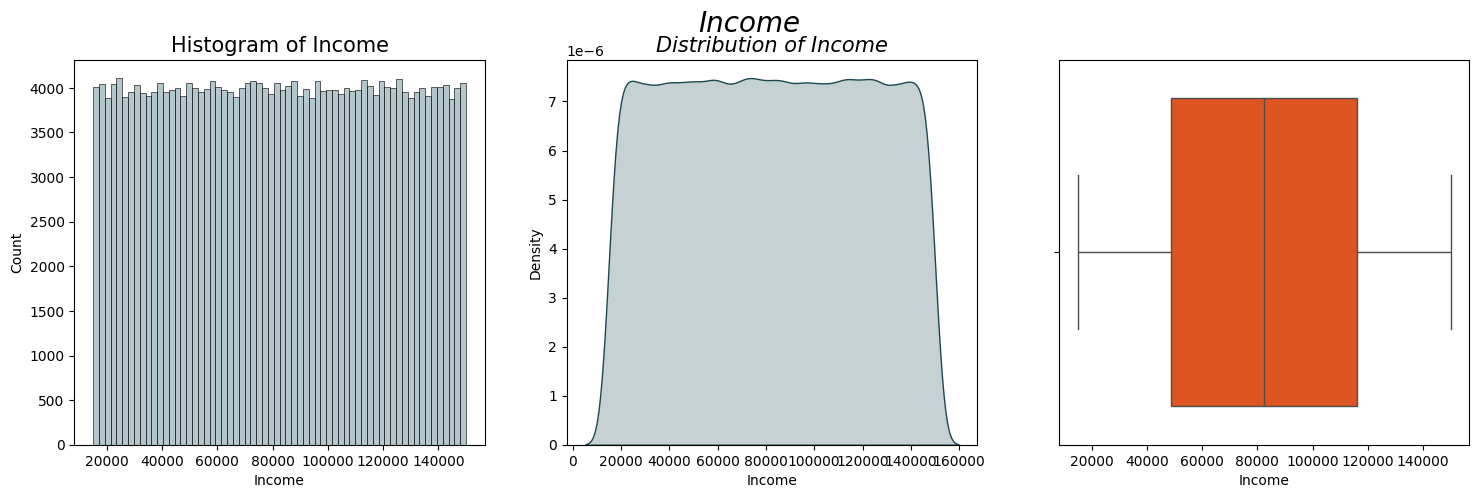

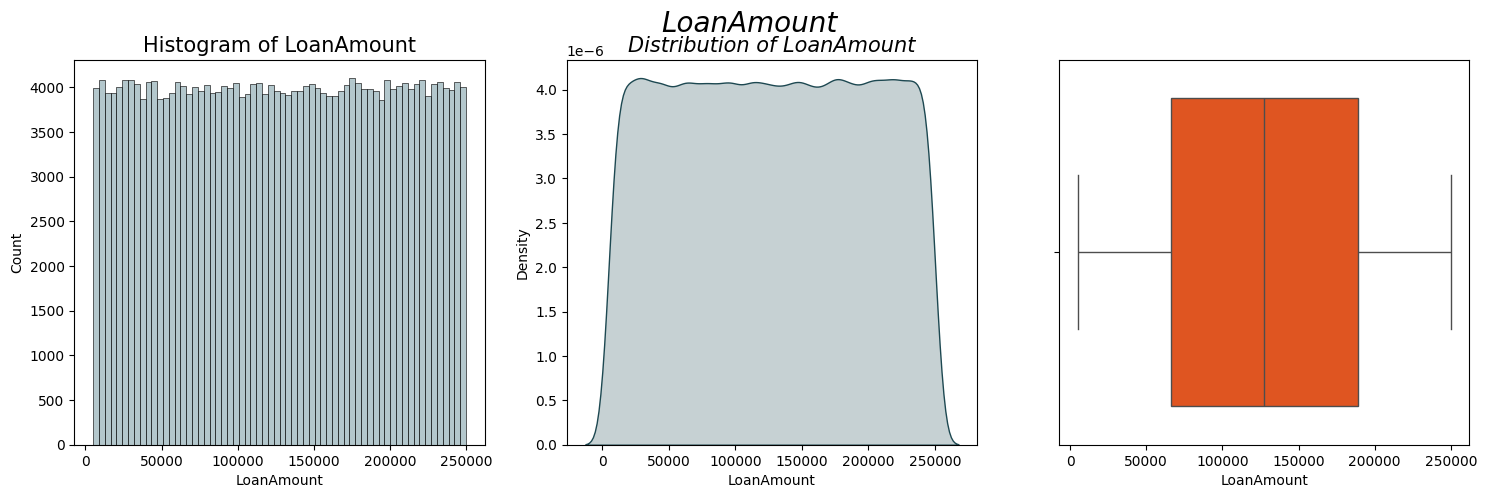

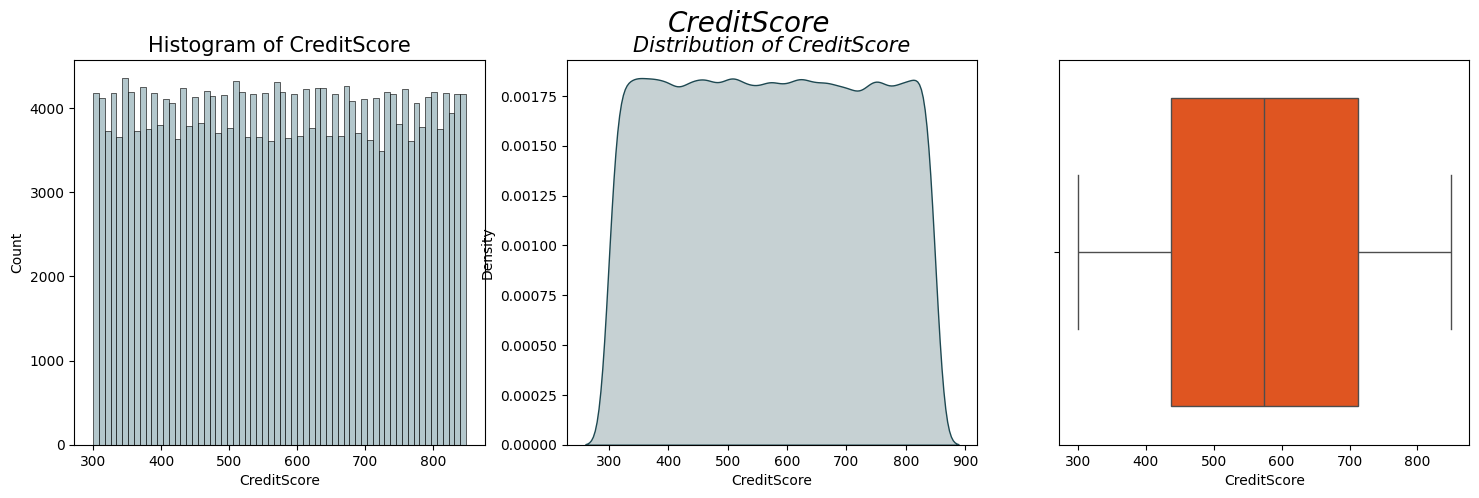

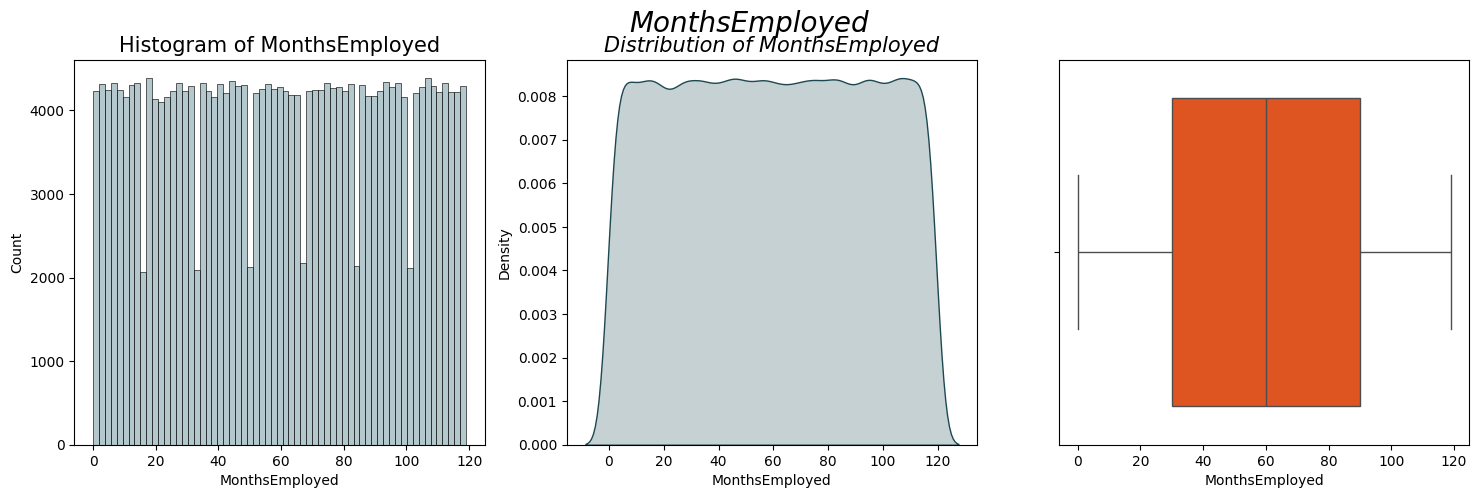

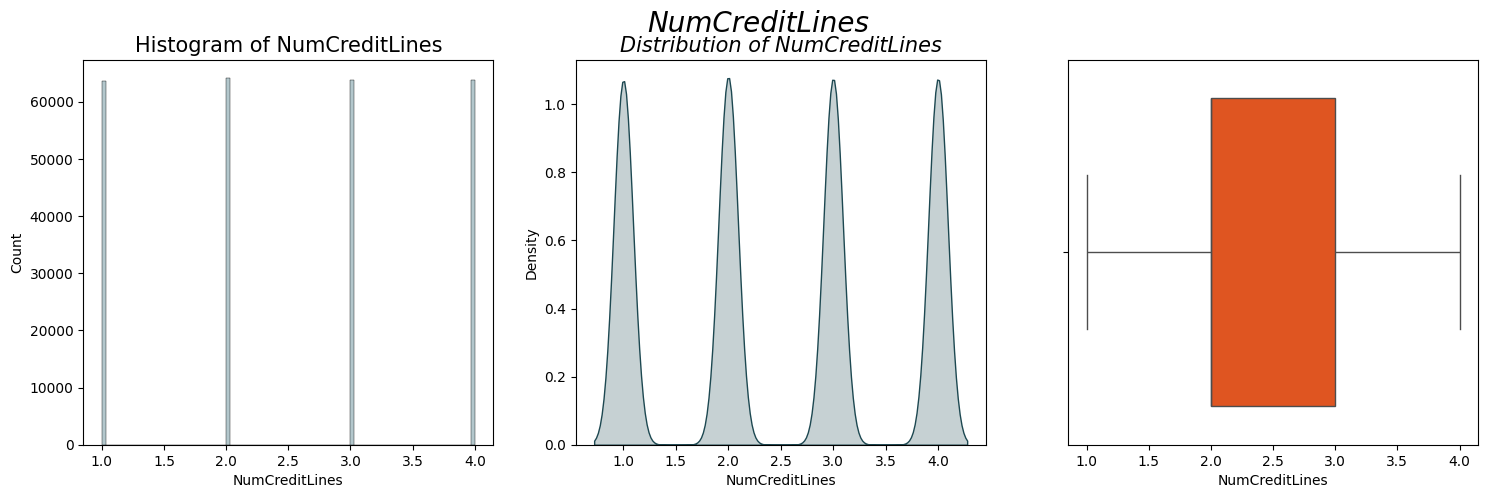

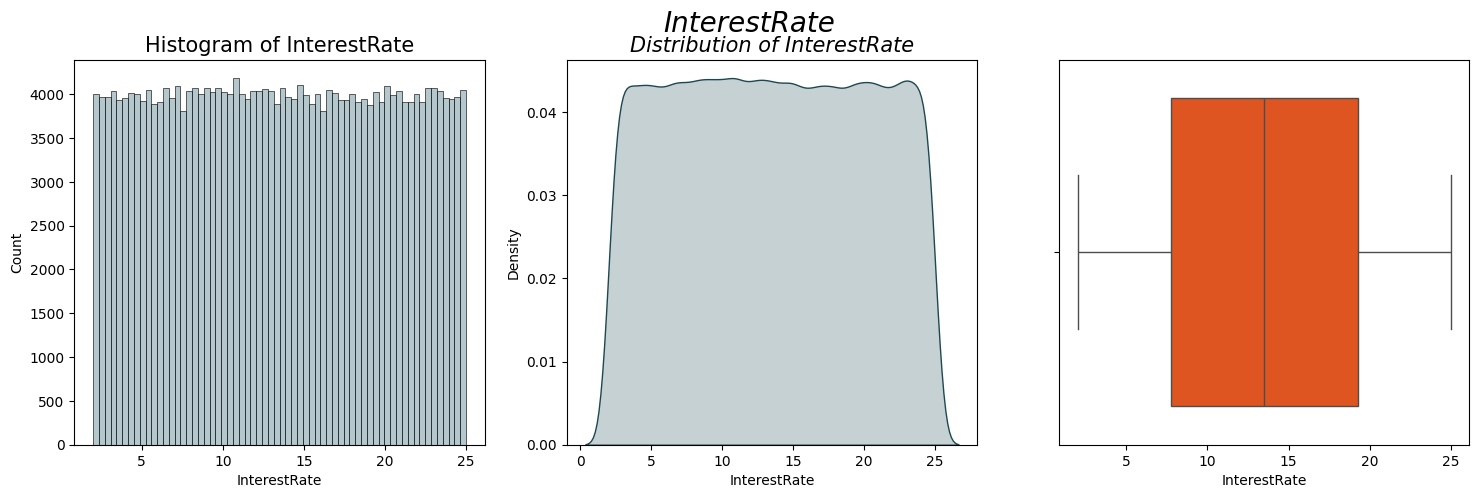

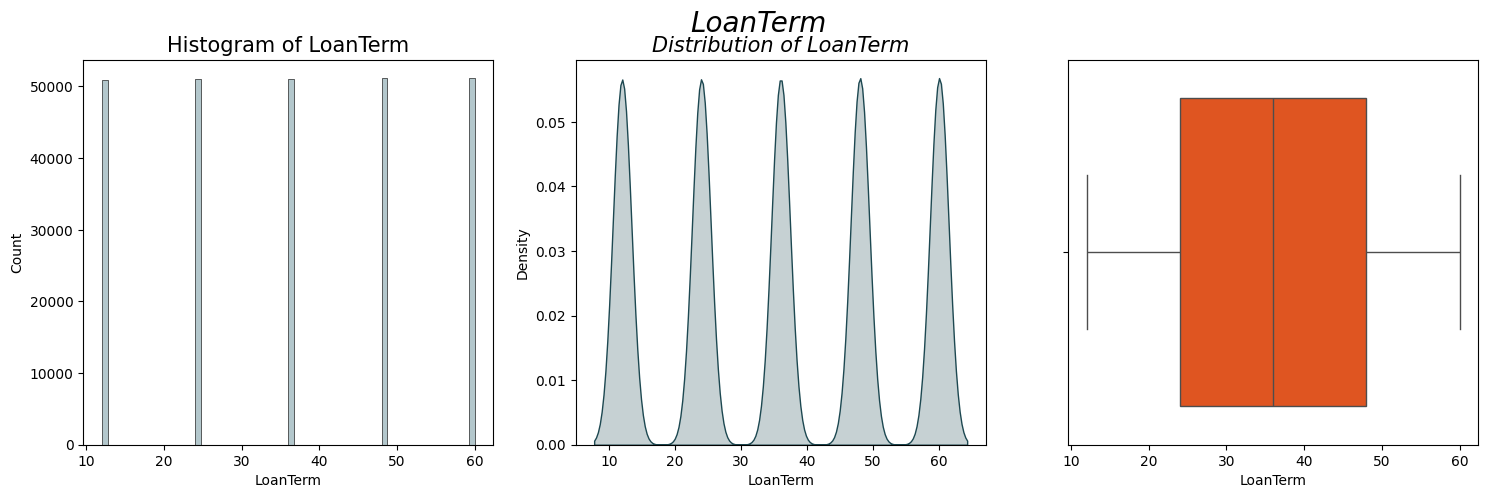

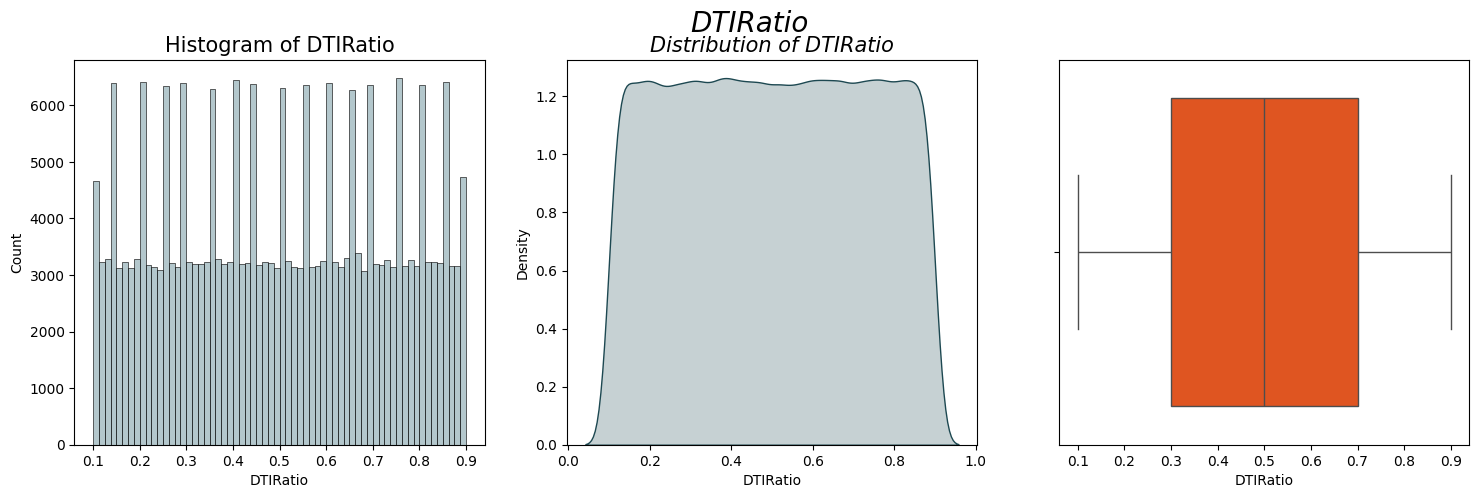

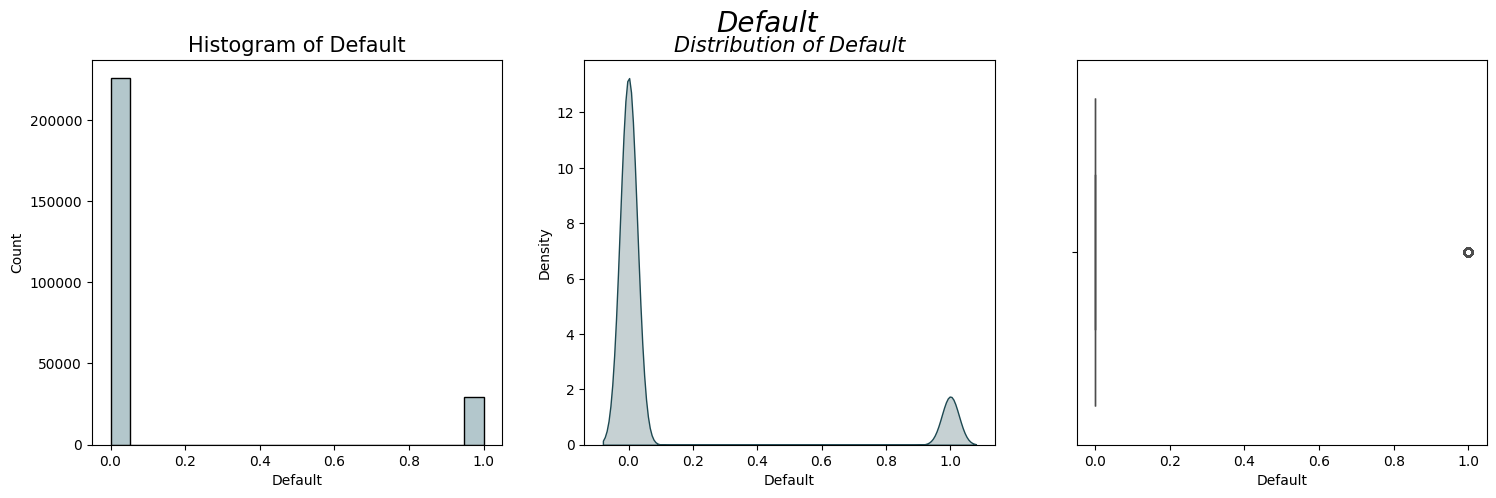

In [31]:
for col in numerical:
    plot_data(col, colors_1)

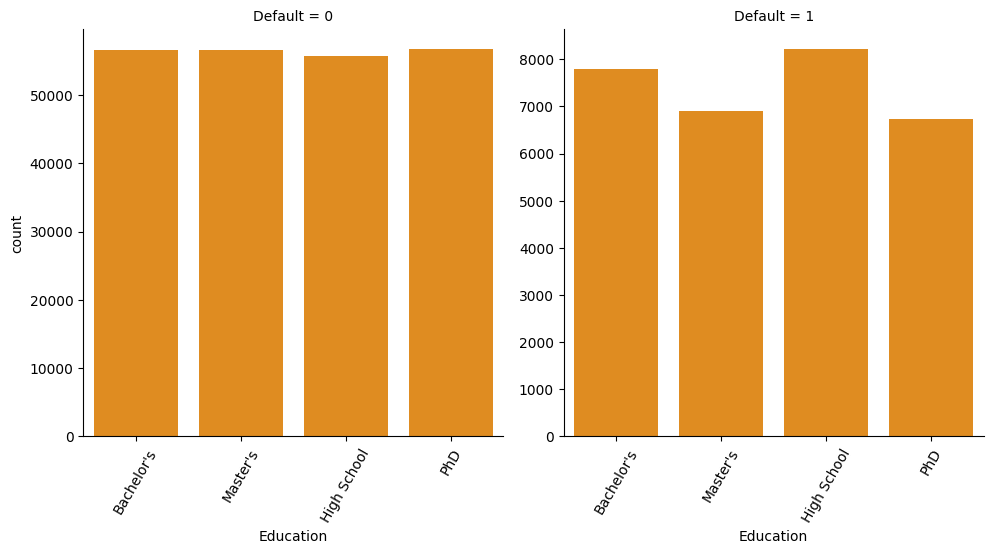

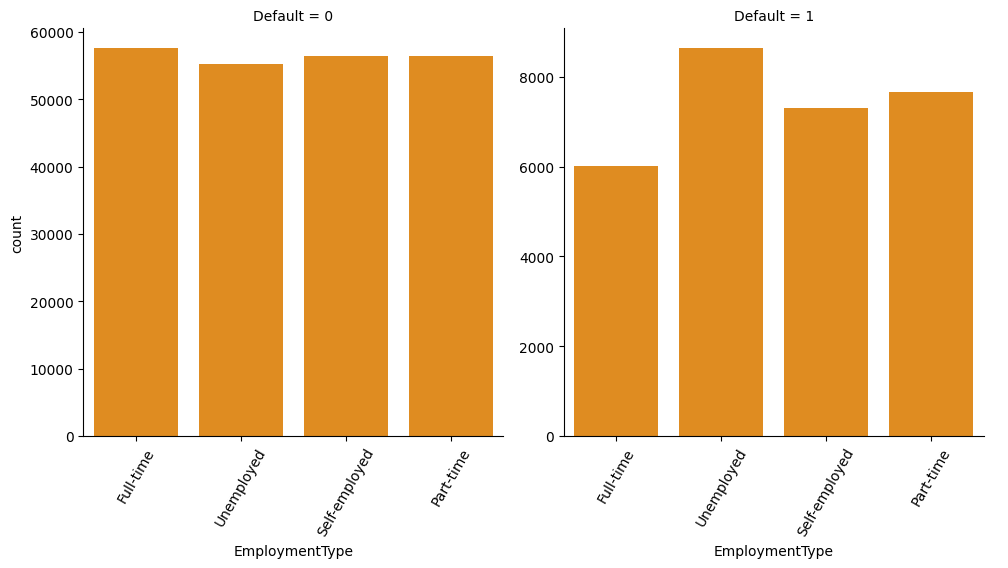

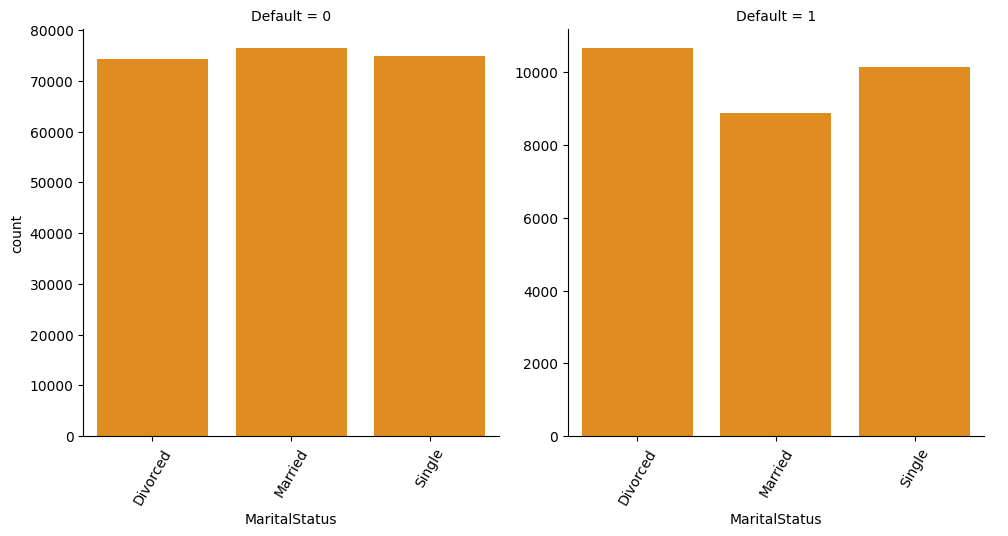

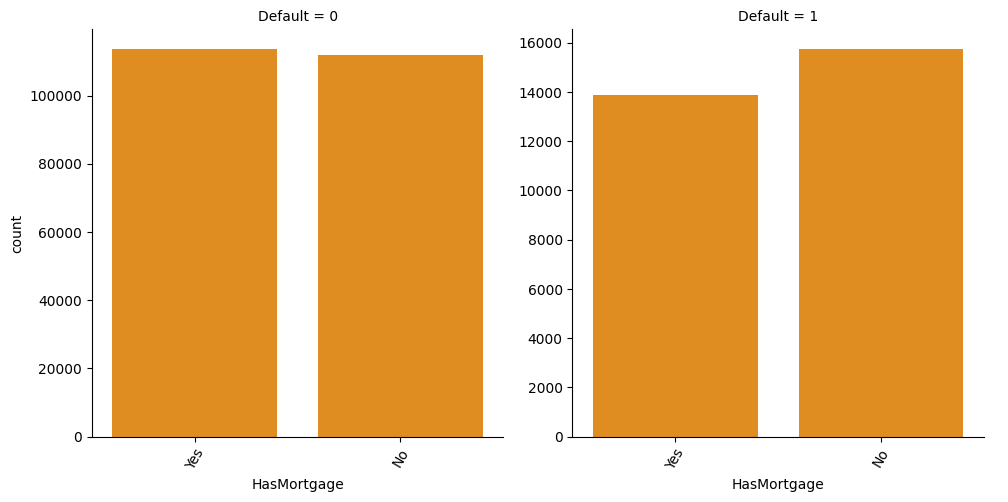

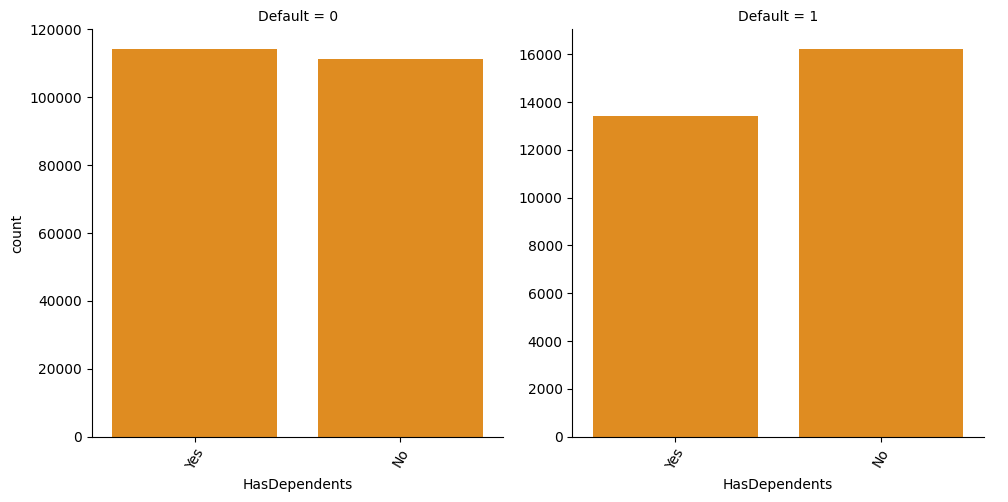

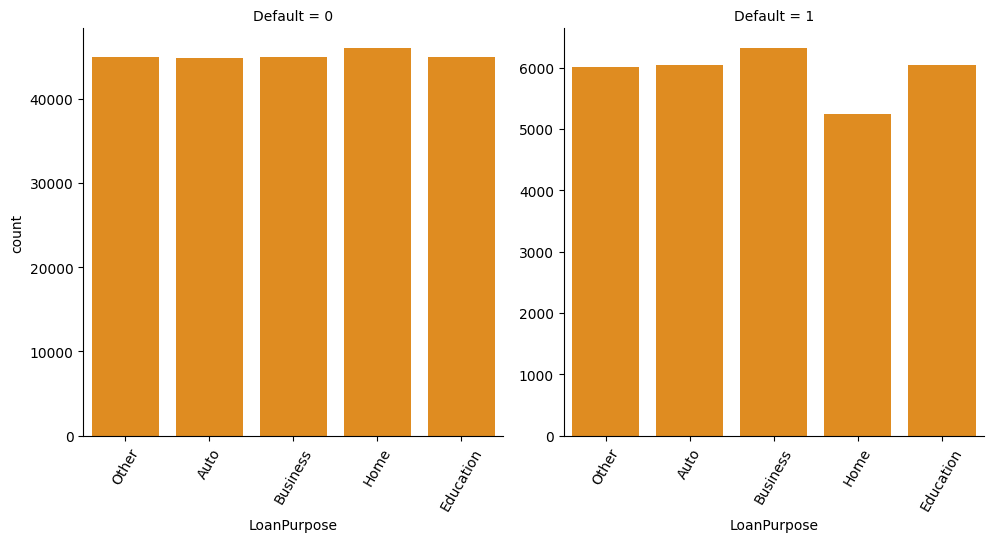

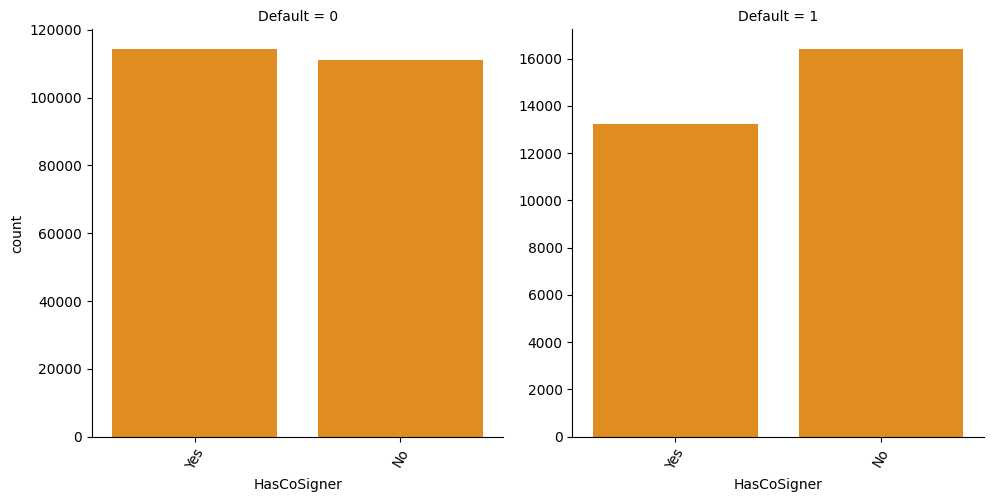

In [32]:
for col in categorical:
    g = sns.catplot(x=col, col='Default', kind='count', data=df, sharey=False, color=colors_1[2])
    g.set_xticklabels(rotation=60)

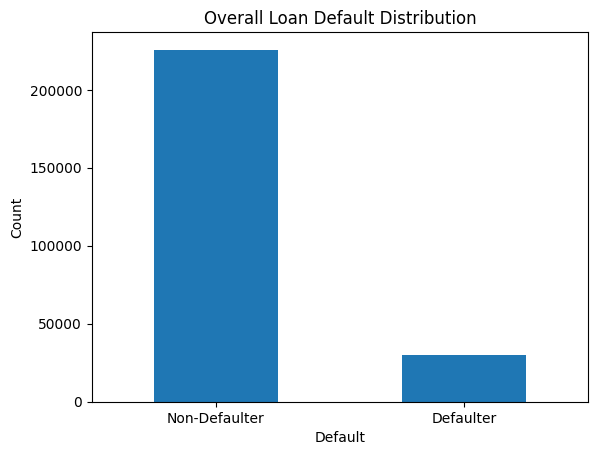

In [33]:
import matplotlib.pyplot as plt

df['Default'].value_counts().plot(kind='bar')
plt.xticks([0,1], ['Non-Defaulter', 'Defaulter'], rotation=0)
plt.title("Overall Loan Default Distribution")
plt.ylabel("Count")
plt.show()


In [37]:
age_default_rate = (
    df.groupby('AgeGroup')['Default']
    .mean()
    .sort_values(ascending=False) * 100
)

age_default_rate


/tmp/ipython-input-1306965040.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')['Default']


,Default
AgeGroup,
18-25,20.555490
26-35,16.078368
36-45,11.548151
46-55,8.449988
56-65,5.859813
65+,4.601888


In [35]:
df.columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education',
       'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents',
       'LoanPurpose', 'HasCoSigner', 'Default'],
      dtype='object')

In [36]:
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Machine Learning Integration for Credit Risk Prediction

In [38]:
y = df['Default']

In [39]:
X = df.drop(columns=[
    'Default',
    'AgeGroup'   # EDA-only feature
])

In [40]:
X = pd.get_dummies(X, drop_first=True)

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [43]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [45]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

In [46]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45170
           1       0.69      0.03      0.06      5900

    accuracy                           0.89     51070
   macro avg       0.79      0.51      0.50     51070
weighted avg       0.86      0.89      0.84     51070

ROC-AUC Score: 0.7391818910106078


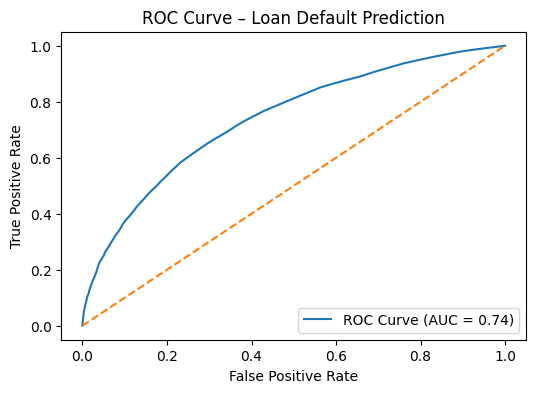

In [77]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label='ROC Curve (AUC = %.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Loan Default Prediction')
plt.legend(loc='lower right')
plt.show()

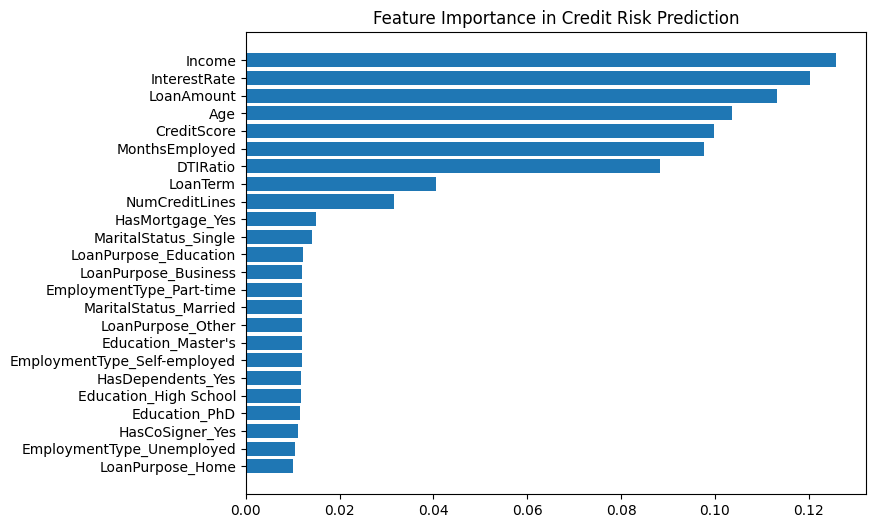

In [47]:
import matplotlib.pyplot as plt
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.title("Feature Importance in Credit Risk Prediction")
plt.show()

In [48]:
df_test = X.iloc[y_test.index].copy()
df_test['Default_Probability'] = y_prob

df_test['Risk_Category'] = pd.cut(
    df_test['Default_Probability'],
    bins=[0, 0.3, 0.6, 1],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

RESULT 1: Model Performance Metrics  show:
	•	Classification Report
	•	ROC-AUC Score

In [50]:
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45170
           1       0.69      0.03      0.06      5900

    accuracy                           0.89     51070
   macro avg       0.79      0.51      0.50     51070
weighted avg       0.86      0.89      0.84     51070

ROC-AUC: 0.7391818910106078


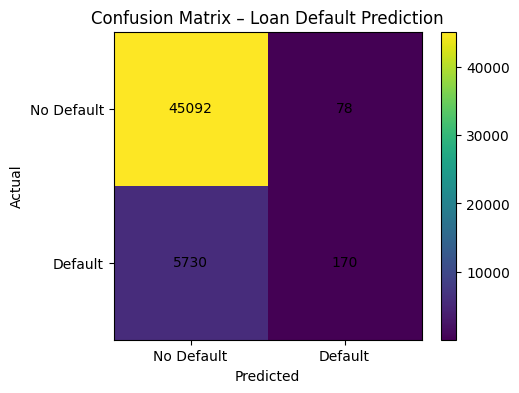

In [75]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title('Confusion Matrix – Loan Default Prediction')
plt.colorbar()
plt.xticks([0,1], ['No Default', 'Default'])
plt.yticks([0,1], ['No Default', 'Default'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

RESULT 2: Confusion Matrix (Decision Proof). Why this matters to banks

It shows:
	•	How many actual defaulters were caught
	•	How many safe customers were correctly approved

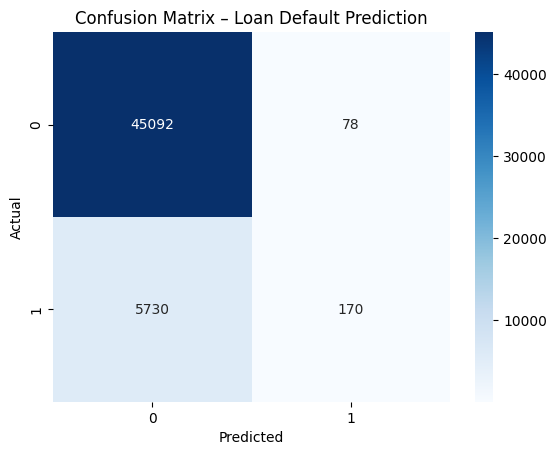

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Loan Default Prediction")
plt.show()

 RESULT 3: Default Probability Output (REAL BANK VALUE) Why this is powerful

Banks don’t want just Yes/No — they want risk level.

In [52]:
results = pd.DataFrame({
    'Actual_Default': y_test.values,
    'Predicted_Default': y_pred,
    'Default_Probability': y_prob
})

results.head(10)

,Actual_Default,Predicted_Default,Default_Probability
0,0,0,0.030
1,0,0,0.035
2,0,0,0.105
3,0,0,0.170
4,0,0,0.155
5,0,0,0.155
6,0,0,0.075
7,0,0,0.055
8,0,0,0.045
9,0,0,0.140


from matplotlib import pyplot as plt
_df_0['Default_Probability'].plot(kind='hist', bins=20, title='Default_Probability')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Actual_Default']
  ys = series['Default_Probability']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_1.sort_values('Actual_Default', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Actual_Default')
_ = plt.ylabel('Default_Probability')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['Actual_Default']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'Actual_Default'}, axis=1)
              .sort_values('Actual_Default', ascending=True))
  xs = counted['Actual_Default']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_2.sort_values('Actual_Default', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Actual_Default')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Predicted_Default']
  ys = series['Default_Probability']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_3.sort_values('Predicted_Default', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Predicted_Default')
_ = plt.ylabel('Default_Probability')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['Predicted_Default']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'Predicted_Default'}, axis=1)
              .sort_values('Predicted_Default', ascending=True))
  xs = counted['Predicted_Default']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_4.sort_values('Predicted_Default', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Predicted_Default')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_5['Default_Probability'].plot(kind='line', figsize=(8, 4), title='Default_Probability')
plt.gca().spines[['top', 'right']].set_visible(False)

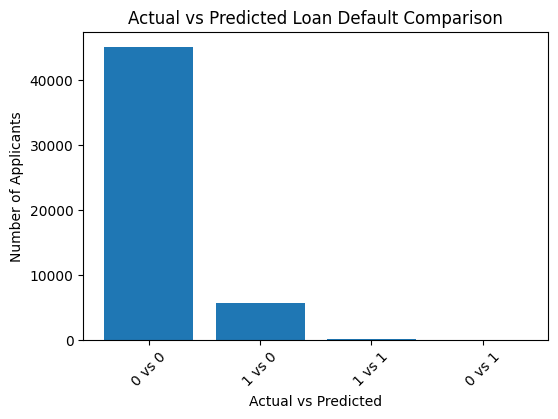

In [74]:
import matplotlib.pyplot as plt
import pandas as pd

comparison = results[['Actual_Default', 'Predicted_Default']].value_counts().reset_index()
comparison.columns = ['Actual_Default', 'Predicted_Default', 'Count']

plt.figure(figsize=(6,4))
plt.bar(
    comparison.index,
    comparison['Count']
)
plt.xticks(
    comparison.index,
    comparison[['Actual_Default','Predicted_Default']].astype(str).agg(' vs '.join, axis=1),
    rotation=45
)
plt.title('Actual vs Predicted Loan Default Comparison')
plt.ylabel('Number of Applicants')
plt.xlabel('Actual vs Predicted')
plt.show()

RESULT 4: Risk Categorization (ACTIONABLE RESULT). Why this proves business usefulness

Now the bank can:
	•	Auto-approve low risk
	•	Manually review medium risk
	•	Reject or price high risk

In [56]:
results['Risk_Category'] = pd.cut(
    results['Default_Probability'],
    bins=[0, 0.3, 0.6, 1],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

results['Risk_Category'].value_counts()

,count
Risk_Category,
Low Risk,47804
Medium Risk,3161
High Risk,46


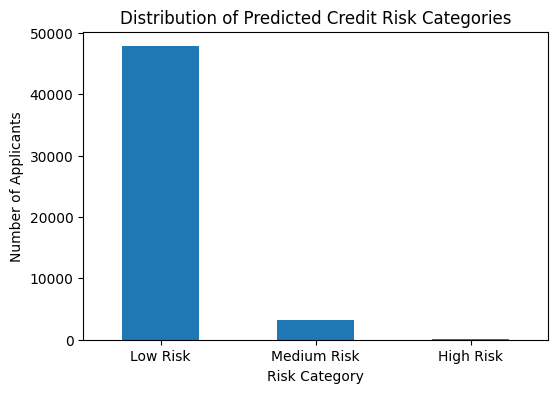

In [73]:
import matplotlib.pyplot as plt

# Step 1: Create risk_counts (THIS WAS MISSING)
risk_counts = results['Risk_Category'].value_counts()

# Step 2: Plot
plt.figure(figsize=(6,4))
risk_counts.plot(kind='bar')
plt.title('Distribution of Predicted Credit Risk Categories')
plt.xlabel('Risk Category')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=0)
plt.show()

 RESULT 5: Loan-Type Wise Risk (Connects to Your EDA) Why this matters

It proves:
	•	Home loans → lower default risk
	•	Personal loans → higher risk


In [62]:
df.columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education',
       'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents',
       'LoanPurpose', 'HasCoSigner', 'Default', 'AgeGroup'],
      dtype='object')

In [65]:
df_test.columns.tolist()

['Age',
 'Income',
 'LoanAmount',
 'CreditScore',
 'MonthsEmployed',
 'NumCreditLines',
 'InterestRate',
 'LoanTerm',
 'DTIRatio',
 'Education',
 'EmploymentType',
 'MaritalStatus',
 'HasMortgage',
 'HasDependents',
 'LoanPurpose',
 'HasCoSigner',
 'Default',
 'AgeGroup',
 'Predicted_Risk']

In [66]:
df_test.groupby('LoanPurpose')['Predicted_Risk'].value_counts(normalize=True)

LoanPurpose  Predicted_Risk
Auto         Low Risk          0.938416
             Medium Risk       0.060594
             High Risk         0.000990
Business     Low Risk          0.931677
             Medium Risk       0.067450
             High Risk         0.000873
Education    Low Risk          0.931973
             Medium Risk       0.067140
             High Risk         0.000887
Home         Low Risk          0.949644
             Medium Risk       0.049779
             High Risk         0.000578
Other        Low Risk          0.933717
             Medium Risk       0.065092
             High Risk         0.001191
Name: proportion, dtype: float64

In [67]:
risk_by_loan = (
    df_test.groupby('LoanPurpose')['Predicted_Risk']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Percentage')
    .reset_index()
)

risk_by_loan

,LoanPurpose,Predicted_Risk,Percentage
0,Auto,Low Risk,93.841584
1,Auto,Medium Risk,6.059406
2,Auto,High Risk,0.099010
3,Business,Low Risk,93.167702
4,Business,Medium Risk,6.744953
5,Business,High Risk,0.087345
6,Education,Low Risk,93.197279
7,Education,Medium Risk,6.713990
8,Education,High Risk,0.088731
9,Home,Low Risk,94.964375


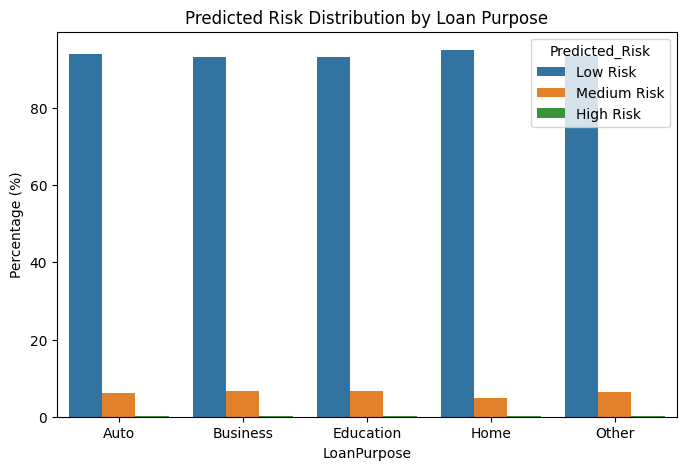

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(
    data=risk_by_loan,
    x='LoanPurpose',
    y='Percentage',
    hue='Predicted_Risk'
)
plt.title('Predicted Risk Distribution by Loan Purpose')
plt.ylabel('Percentage (%)')
plt.show()

DEFAULT PROBABILITY FOR EACH APPLICANT (TABLE)

In [78]:
results[['Default_Probability']].head(10)

,Default_Probability
0,0.030
1,0.035
2,0.105
3,0.170
4,0.155
5,0.155
6,0.075
7,0.055
8,0.045
9,0.140


from matplotlib import pyplot as plt
_df_6['Default_Probability'].plot(kind='hist', bins=20, title='Default_Probability')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_7['Default_Probability'].plot(kind='line', figsize=(8, 4), title='Default_Probability')
plt.gca().spines[['top', 'right']].set_visible(False)

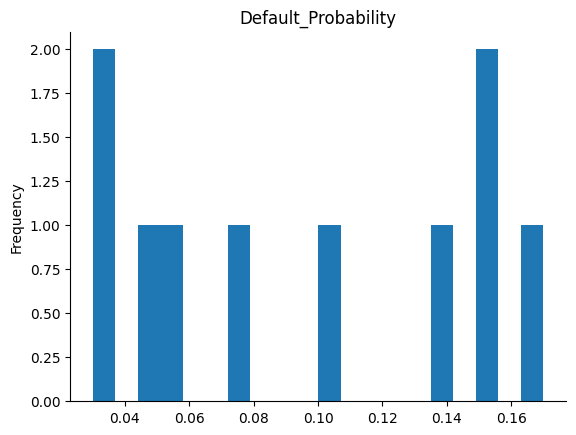

In [79]:
from matplotlib import pyplot as plt
_df_6['Default_Probability'].plot(kind='hist', bins=20, title='Default_Probability')
plt.gca().spines[['top', 'right',]].set_visible(False)

RISK CATEGORY DISTRIBUTION (GRAPH + TABLE)

In [80]:
import matplotlib.pyplot as plt

risk_counts = results['Risk_Category'].value_counts()
risk_counts

,count
Risk_Category,
Low Risk,47804
Medium Risk,3161
High Risk,46


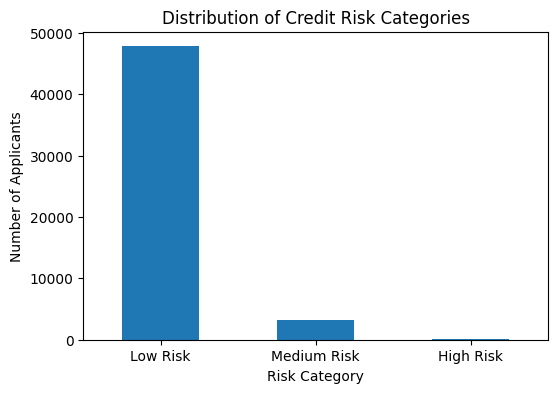

In [81]:
plt.figure(figsize=(6,4))
risk_counts.plot(kind='bar')
plt.title('Distribution of Credit Risk Categories')
plt.xlabel('Risk Category')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=0)
plt.show()

LOAN PURPOSE vs RISK (TABLE + GRAPH)

In [82]:
df_test = df.loc[y_test.index].copy()
df_test['Risk_Category'] = results['Risk_Category'].values

In [83]:
loan_risk = (
    df_test.groupby('LoanPurpose')['Risk_Category']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Percentage')
    .reset_index()
)

loan_risk

,LoanPurpose,Risk_Category,Percentage
0,Auto,Low Risk,93.841584
1,Auto,Medium Risk,6.059406
2,Auto,High Risk,0.099010
3,Business,Low Risk,93.167702
4,Business,Medium Risk,6.744953
5,Business,High Risk,0.087345
6,Education,Low Risk,93.197279
7,Education,Medium Risk,6.713990
8,Education,High Risk,0.088731
9,Home,Low Risk,94.964375


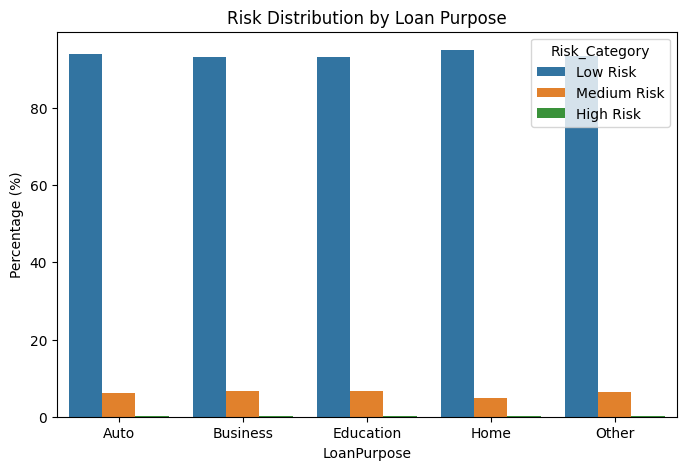

In [84]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(
    data=loan_risk,
    x='LoanPurpose',
    y='Percentage',
    hue='Risk_Category'
)
plt.title('Risk Distribution by Loan Purpose')
plt.ylabel('Percentage (%)')
plt.show()

TOP FACTORS CAUSING DEFAULT (FEATURE IMPORTANCE).  What parameters should we check before lending?

In [85]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
1,Income,0.125869
6,InterestRate,0.120182
2,LoanAmount,0.113161
0,Age,0.103560
3,CreditScore,0.099698
4,MonthsEmployed,0.097602
8,DTIRatio,0.088378
7,LoanTerm,0.040614
5,NumCreditLines,0.031528
17,HasMortgage_Yes,0.014863


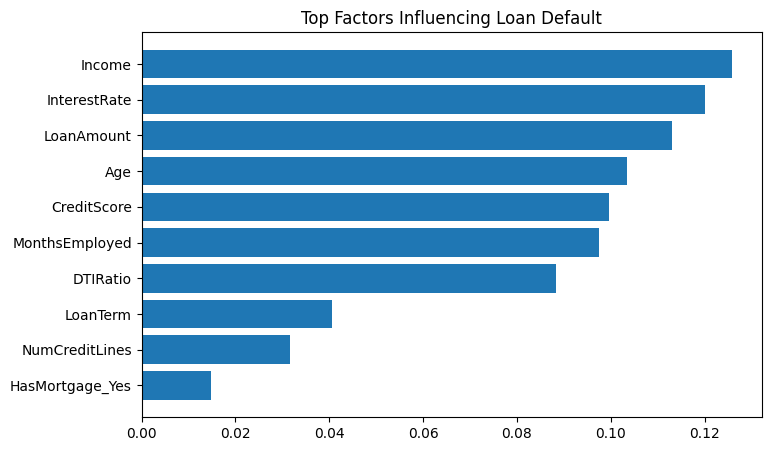

In [86]:
plt.figure(figsize=(8,5))
plt.barh(
    feature_importance['Feature'][:10],
    feature_importance['Importance'][:10]
)
plt.title('Top Factors Influencing Loan Default')
plt.gca().invert_yaxis()
plt.show()

 INCOME vs DEFAULT RISK (GRAPH)

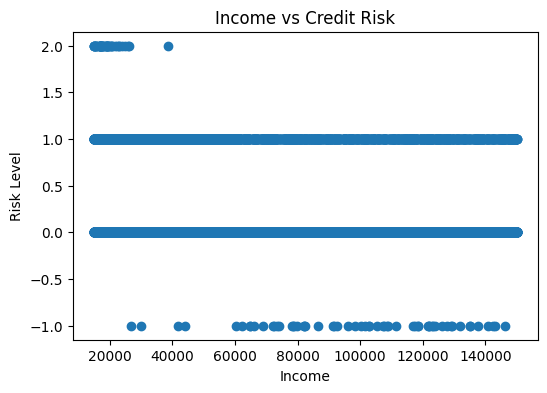

In [87]:
plt.figure(figsize=(6,4))
plt.scatter(df_test['Income'], df_test['Risk_Category'].cat.codes)
plt.xlabel('Income')
plt.ylabel('Risk Level')
plt.title('Income vs Credit Risk')
plt.show()

DTI RATIO vs DEFAULT RISK (GRAPH) How does debt burden affect default?

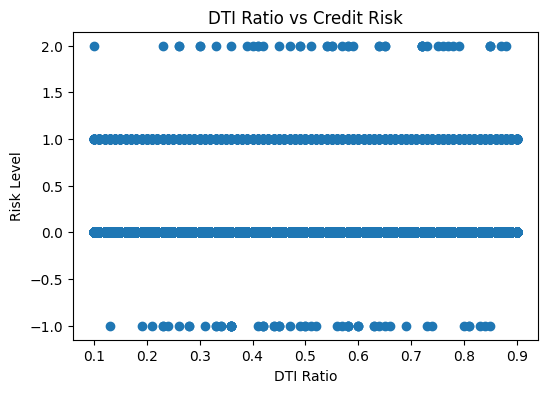

In [88]:
plt.figure(figsize=(6,4))
plt.scatter(df_test['DTIRatio'], df_test['Risk_Category'].cat.codes)
plt.xlabel('DTI Ratio')
plt.ylabel('Risk Level')
plt.title('DTI Ratio vs Credit Risk')
plt.show()

CREDIT SCORE vs DEFAULT PROBABILITY (GRAPH) How important is credit score?

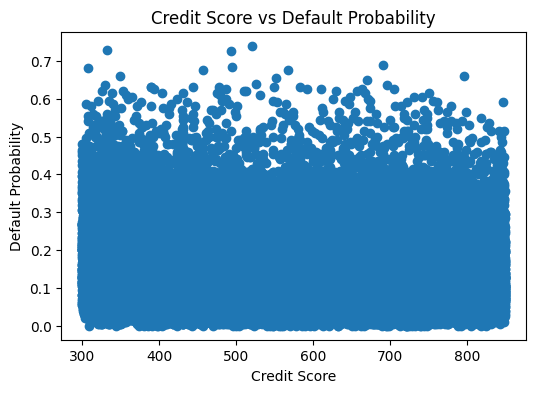

In [89]:
plt.figure(figsize=(6,4))
plt.scatter(df_test['CreditScore'], results['Default_Probability'])
plt.xlabel('Credit Score')
plt.ylabel('Default Probability')
plt.title('Credit Score vs Default Probability')
plt.show()

 EMPLOYMENT TYPE vs RISK (TABLE) Which employment types are riskier?

In [90]:
employment_risk = (
    df_test.groupby('EmploymentType')['Risk_Category']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Percentage')
    .reset_index()
)

employment_risk

,EmploymentType,Risk_Category,Percentage
0,Full-time,Low Risk,94.863526
1,Full-time,Medium Risk,5.049949
2,Full-time,High Risk,0.086526
3,Part-time,Low Risk,93.908109
4,Part-time,Medium Risk,6.013082
5,Part-time,High Risk,0.078808
6,Self-employed,Low Risk,94.462260
7,Self-employed,Medium Risk,5.506453
8,Self-employed,High Risk,0.031287
9,Unemployed,Low Risk,91.632876


from matplotlib import pyplot as plt
employment_risk['Percentage'].plot(kind='hist', bins=20, title='Percentage')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
employment_risk.groupby('EmploymentType').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
employment_risk['Percentage'].plot(kind='line', figsize=(8, 4), title='Percentage')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(employment_risk['EmploymentType'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(employment_risk, x='Percentage', y='EmploymentType', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

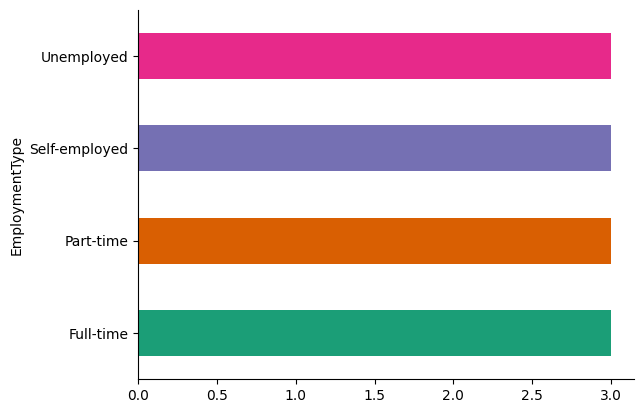

In [91]:
from matplotlib import pyplot as plt
import seaborn as sns
employment_risk.groupby('EmploymentType').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

CO-SIGNER IMPACT (TABLE + GRAPH) Does having a co-signer reduce risk?

In [92]:
cosigner_risk = (
    df_test.groupby('HasCoSigner')['Risk_Category']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Percentage')
    .reset_index()
)

cosigner_risk

,HasCoSigner,Risk_Category,Percentage
0,No,Low Risk,92.384793
1,No,Medium Risk,7.482088
2,No,High Risk,0.133119
3,Yes,Low Risk,95.045151
4,Yes,Medium Risk,4.907735
5,Yes,High Risk,0.047114


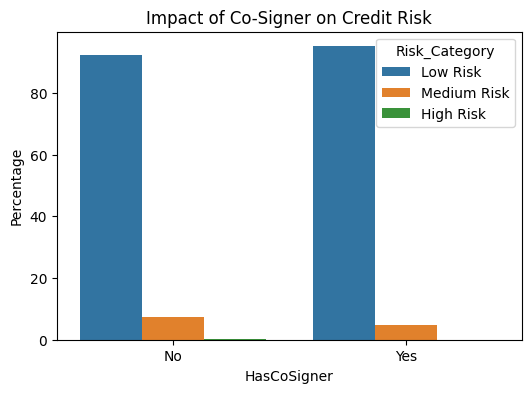

In [93]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=cosigner_risk,
    x='HasCoSigner',
    y='Percentage',
    hue='Risk_Category'
)
plt.title('Impact of Co-Signer on Credit Risk')
plt.show()

 WHO SHOULD BE MANUALLY REVIEWED? (TABLE)

In [94]:
manual_review = results[
    (results['Default_Probability'] >= 0.3) &
    (results['Default_Probability'] <= 0.6)
]

manual_review.head(10)

,Actual_Default,Predicted_Default,Default_Probability,Risk_Category
22,1,0,0.340,Medium Risk
47,1,1,0.560,Medium Risk
65,0,0,0.335,Medium Risk
68,0,0,0.320,Medium Risk
103,0,0,0.475,Medium Risk
105,1,0,0.380,Medium Risk
111,0,0,0.375,Medium Risk
115,1,0,0.365,Medium Risk
124,1,0,0.500,Medium Risk
139,0,0,0.365,Medium Risk


from matplotlib import pyplot as plt
_df_8['Actual_Default'].plot(kind='hist', bins=20, title='Actual_Default')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_9['Predicted_Default'].plot(kind='hist', bins=20, title='Predicted_Default')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_10['Default_Probability'].plot(kind='hist', bins=20, title='Default_Probability')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_11.plot(kind='scatter', x='Actual_Default', y='Predicted_Default', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_12.plot(kind='scatter', x='Predicted_Default', y='Default_Probability', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_13['Actual_Default'].plot(kind='line', figsize=(8, 4), title='Actual_Default')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_14['Predicted_Default'].plot(kind='line', figsize=(8, 4), title='Predicted_Default')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_15['Default_Probability'].plot(kind='line', figsize=(8, 4), title='Default_Probability')
plt.gca().spines[['top', 'right']].set_visible(False)

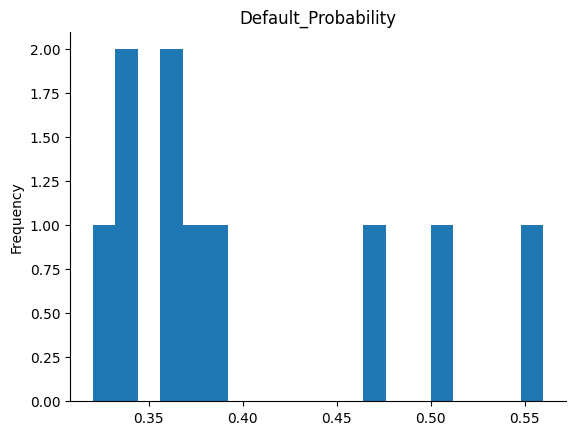

In [95]:
from matplotlib import pyplot as plt
_df_10['Default_Probability'].plot(kind='hist', bins=20, title='Default_Probability')
plt.gca().spines[['top', 'right',]].set_visible(False)

POLICY SIMULATION (CHANGE THRESHOLD). What if we reject applicants above 50% risk?

In [96]:
results['Strict_Policy'] = results['Default_Probability'] > 0.5
results['Strict_Policy'].value_counts()

,count
Strict_Policy,
False,50822
True,248
